<a href="https://colab.research.google.com/github/preranasinha20/ato/blob/main/PBL_MT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd

df = pd.read_csv('/content/siem_logs_only.csv')

print(df.shape)
df.head()

(100000, 2)


,raw_log,isFraud
0,[2026-01-12 14:00:00] EVENT=TRANSACTION USER=C...,0
1,[2026-01-01 15:00:00] EVENT=TRANSACTION USER=C...,0
2,[2026-01-01 10:00:00] EVENT=TRANSACTION USER=C...,0
3,[2026-01-17 19:00:00] EVENT=TRANSACTION USER=C...,0
4,[2026-01-09 14:00:00] EVENT=TRANSACTION USER=C...,0


In [86]:
import re

def parse_log(log):
    data = {}

    patterns = {
        'timestamp': r'\[(.*?)\]',
        'transaction_type': r'ACTION=(\w+)',
        'amount': r'AMOUNT=(\d+\.?\d*)',
        'device_type': r'DEVICE=(\w+)',
        'os': r'OS=(\w+)',
        'browser': r'BROWSER=(\w+)',
        'ip_address': r'IP=([\d\.]+)',
        'ip_city': r'CITY=(\w+)',
        'login_method': r'LOGIN_METHOD=(\w+)',
        'failed_login_count': r'FAILED_LOGINS=(\d+)',
        'is_new_device': r'NEW_DEVICE=(\d+)',
        'event_velocity': r'VELOCITY=(\d+\.?\d*)'
    }

    for key, pattern in patterns.items():
        match = re.search(pattern, log)
        data[key] = match.group(1) if match else None

    return data


In [87]:
parsed = df['raw_log'].apply(parse_log)
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df.head()

,timestamp,transaction_type,amount,device_type,os,browser,ip_address,ip_city,login_method,failed_login_count,is_new_device,event_velocity
0,2026-01-12 14:00:00,CASH_IN,330218.42,mobile,Android,Chrome,132.131.111.179,Bangalore,otp,2,1,1.26
1,2026-01-01 15:00:00,PAYMENT,11647.08,mobile,Android,Edge,24.222.32.170,Mumbai,otp,1,1,1.61
2,2026-01-01 10:00:00,CASH_IN,152264.21,desktop,Android,Edge,150.68.241.98,Mumbai,password,1,1,2.25
3,2026-01-17 19:00:00,TRANSFER,1551760.63,desktop,iOS,Safari,53.47.201.11,Pune,password,0,0,2.19
4,2026-01-09 14:00:00,CASH_IN,78172.3,mobile,Windows,Chrome,140.110.55.26,Delhi,password,1,0,0.48


In [88]:
import numpy as np
import pandas as pd

# 1. Convert to numeric
parsed_df['amount'] = pd.to_numeric(parsed_df['amount'], errors='coerce')
parsed_df['failed_login_count'] = pd.to_numeric(parsed_df['failed_login_count'], errors='coerce')
parsed_df['event_velocity'] = pd.to_numeric(parsed_df['event_velocity'], errors='coerce')
parsed_df['is_new_device'] = pd.to_numeric(parsed_df['is_new_device'], errors='coerce')

# 2. Add Log Transformation to amount (CRITICAL to lower ROC-AUC)
# This makes it harder for the model to "cheat" on high amounts
parsed_df['amount'] = np.log1p(parsed_df['amount'].fillna(0))

# 3. Timestamp features
parsed_df['timestamp'] = pd.to_datetime(parsed_df['timestamp'], errors='coerce')
parsed_df['event_hour'] = parsed_df['timestamp'].dt.hour
parsed_df['event_day'] = parsed_df['timestamp'].dt.day
parsed_df['event_month'] = parsed_df['timestamp'].dt.month

In [89]:
parsed_df = parsed_df.fillna({
    'amount': 0,
    'failed_login_count': 0,
    'event_velocity': 0,
    'is_new_device': 0,
    'device_type': 'unknown',
    'os': 'unknown',
    'browser': 'unknown',
    'ip_city': 'unknown',
    'login_method': 'unknown'
})


In [90]:
parsed_df.shape

(100000, 15)

In [91]:
parsed_df['isFraud'] = df['isFraud']

# Drop the bad row
parsed_df = parsed_df.dropna(subset=['isFraud'])

In [92]:
numeric_cols = [
    'amount',
    'failed_login_count',
    'event_velocity',
    'is_new_device',
    'event_hour',
    'event_day',
    'event_month'
]

categorical_cols = [
    'transaction_type',
    'device_type',
    'os',
    'browser',
    'ip_city',
    'login_method'
]


In [93]:
parsed_df['isFraud'].isnull().sum()

np.int64(0)

In [142]:
from sklearn.model_selection import train_test_split

X = parsed_df.drop(columns=['isFraud', 'timestamp', 'ip_address'])
y = parsed_df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


Autoencoder

In [143]:
# Use ONLY normal transactions
X_train_normal = X_train[y_train == 0]

In [144]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train_normal)
X_test_processed = preprocessor.transform(X_test)

In [145]:
import tensorflow as tf
from tensorflow.keras import layers, models

# The input_dim is determined by your processed features
input_dim = X_train_processed.shape[1]

# We are tightening the bottleneck from 32 to 8 or 16
autoencoder = models.Sequential([
    # Encoder
    layers.Dense(32, activation='relu', input_shape=(input_dim,)),
    layers.Dense(16, activation='relu'),

    # Bottleneck (The "Essence" Layer)
    layers.Dense(8, activation='relu'),

    # Decoder
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [146]:
autoencoder.fit(
    X_train_processed, X_train_processed,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2507 - val_loss: 0.1598
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1455 - val_loss: 0.1286
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1247 - val_loss: 0.1243
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1228 - val_loss: 0.1228
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1221 - val_loss: 0.1216
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1207 - val_loss: 0.1207
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1198 - val_loss: 0.1201
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1194 - val_loss: 0.1198
Epoch 9/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1190 - val_loss: 0.1194
Epoch 10/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1187 - val_loss: 0.1187
Epoch 11/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1183 - val_loss: 0.1183
Epoch 12/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [147]:
reconstructions = autoencoder.predict(X_test_processed)

import numpy as np
mse = np.mean(np.power(X_test_processed - reconstructions, 2), axis=1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [148]:
threshold = np.percentile(mse, 95)  # tune this

ae_preds = (mse > threshold).astype(int)


In [149]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

print("AUTOENCODER RESULTS ")
print(classification_report(y_test, ae_preds))
print("ROC-AUC:", roc_auc_score(y_test, mse))
print("PR-AUC:", average_precision_score(y_test, mse))


AUTOENCODER RESULTS 
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     19972
           1       0.01      0.50      0.03        28

    accuracy                           0.95     20000
   macro avg       0.51      0.73      0.50     20000
weighted avg       1.00      0.95      0.97     20000

ROC-AUC: 0.8098391319275556
PR-AUC: 0.0632770244202601


Random Forest

In [150]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'failed_login_count',
                                                   'event_velocity',
                                                   'is_new_device',
                                                   'event_hour', 'event_day',
                                                   'event_month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'device_type', 'os',
                                                   'browser', 'ip_city',
                                                   'login_method'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [151]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("SIEM PIPELINE RESULTS ")
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("PR-AUC:", average_precision_score(y_test, probs))


SIEM PIPELINE RESULTS 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       1.00      0.82      0.90        28

    accuracy                           1.00     20000
   macro avg       1.00      0.91      0.95     20000
weighted avg       1.00      1.00      1.00     20000

ROC-AUC: 0.9999982117822095
PR-AUC: 0.9987684729064039


XGBoost

In [152]:
!pip install xgboost

In [153]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=50,       # Lowered from 200
        max_depth=2,           # Very shallow trees
        gamma=10,              # High penalty for making new splits
        reg_alpha=20,          # High L1 regularization
        learning_rate=0.01,    # Very slow learning
        scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'failed_login_count',
                                                   'event_velocity',
                                                   'is_new_device',
                                                   'event_hour', 'event_day',
                                                   'event_month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'device_type', 'os',
                                                   'browser', 'ip_city',
                                                   'login_method'])])),
                ('model',
                 XGBClassifier(base_sco...
                               feature_types=None, feature_weights=None,
                               gamma=10, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [154]:
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS ")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("PR-AUC:", average_precision_score(y_test, xgb_probs))

XGBOOST RESULTS 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19972
           1       0.11      0.96      0.19        28

    accuracy                           0.99     20000
   macro avg       0.55      0.98      0.59     20000
weighted avg       1.00      0.99      0.99     20000

ROC-AUC: 0.9930921146748305
PR-AUC: 0.25443703087786557


Score for anamoly and fraud

In [155]:
import numpy as np

# ✅ Use SAME preprocessing (DO NOT refit)
X_train_normal = X_train[y_train == 0]

# Transform using already fitted preprocessor (from RF/XGB pipeline)
X_train_proc = preprocessor.transform(X_train_normal)
X_test_proc  = preprocessor.transform(X_test)

# --- Reconstruction ---
recon_train = autoencoder.predict(X_train_proc)
recon_test  = autoencoder.predict(X_test_proc)

# --- Reconstruction error (MSE) ---
mse_train = np.mean((X_train_proc - recon_train) ** 2, axis=1)
mse_test  = np.mean((X_test_proc  - recon_test)  ** 2, axis=1)

# --- Normalize (VERY IMPORTANT for combining) ---
ae_score_train = (mse_train - mse_train.min()) / (mse_train.max() - mse_train.min() + 1e-8)
ae_score_test  = (mse_test  - mse_test.min())  / (mse_test.max()  - mse_test.min()  + 1e-8)


2497/2497 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [156]:
import numpy as np


ae_norm = (ae_score_test - ae_score_test.min()) / (ae_score_test.max() - ae_score_test.min() + 1e-8)

final_score = (
    0.5 * ae_norm +
    0.25 * probs +
    0.25 * xgb_probs
)

threshold = np.percentile(final_score, 97)
final_preds = (final_score > threshold).astype(int)

print("HYBRID RISK FUSION COMPLETE ")

HYBRID RISK FUSION COMPLETE 


In [157]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

print("HYBRID MODEL RESULTS ")
print(classification_report(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_score))
print("PR-AUC:", average_precision_score(y_test, final_score))


HYBRID MODEL RESULTS 
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     19972
           1       0.04      0.96      0.09        28

    accuracy                           0.97     20000
   macro avg       0.52      0.97      0.54     20000
weighted avg       1.00      0.97      0.98     20000

ROC-AUC: 0.998900246058768
PR-AUC: 0.8613672680888635


In [158]:
# Convert hybrid score to interpretable risk score (0–100)
risk_score = final_score * 100

import pandas as pd

results_df = pd.DataFrame({
    "actual": y_test.values,
    "risk_score": risk_score,
    "prediction": final_preds
})

results_df.head()

,actual,risk_score,prediction
0,0,11.966313,0
1,0,10.190633,0
2,0,11.430910,0
3,0,13.742509,0
4,0,10.502575,0


In [159]:
# Convert numeric risk score into alert level

def risk_level(score):
    if score >= 90:
        return "CRITICAL"
    elif score >= 70:
        return "HIGH"
    elif score >= 40:
        return "MEDIUM"
    else:
        return "LOW"

results_df["risk_level"] = results_df["risk_score"].apply(risk_level)

results_df.head()

,actual,risk_score,prediction,risk_level
0,0,11.966313,0,LOW
1,0,10.190633,0,LOW
2,0,11.430910,0,LOW
3,0,13.742509,0,LOW
4,0,10.502575,0,LOW


In [160]:
results_df["risk_level"].value_counts()

,count
risk_level,
LOW,19985
MEDIUM,15


In [161]:
import shap
explainer = shap.TreeExplainer(xgb_model.named_steps["model"])

X_test_proc = xgb_model.named_steps["preprocessing"].transform(X_test)

shap_values = explainer.shap_values(X_test_proc)

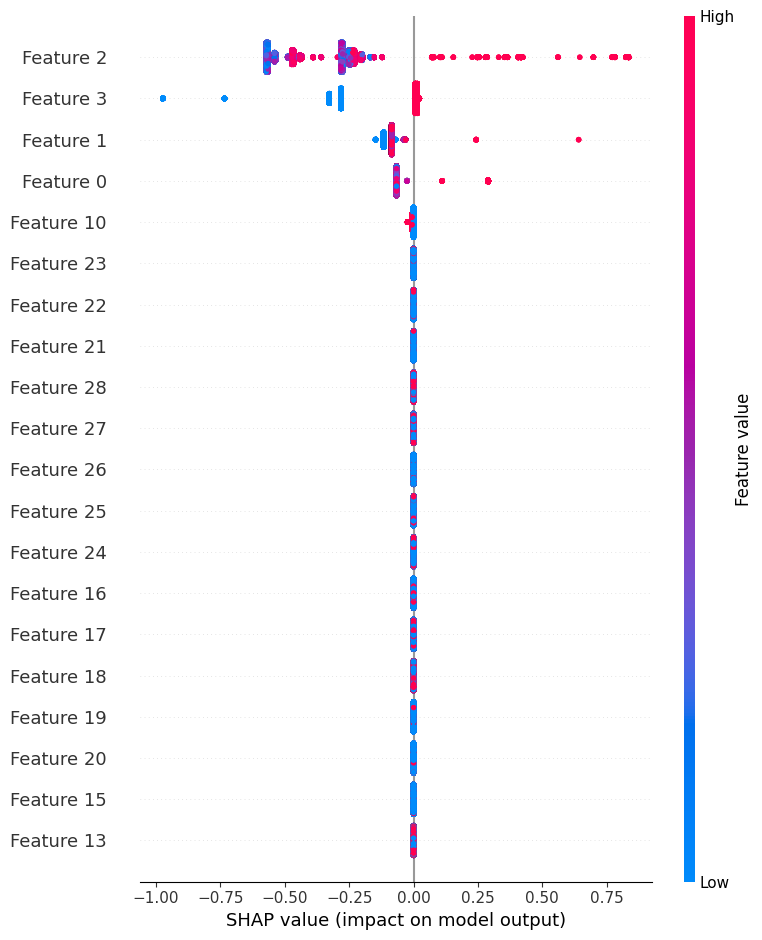

In [162]:
shap.summary_plot(shap_values, X_test_proc)

In [163]:
# create a simulated suspicious login
scenario = X_test.iloc[0].copy()

scenario["failed_login_count"] = 10
scenario["is_new_device"] = 1
scenario["event_velocity"] = 15

scenario_df = pd.DataFrame([scenario])

rf_prob = model.predict_proba(scenario_df)[:,1]
xgb_prob = xgb_model.predict_proba(scenario_df)[:,1]

print("Random Forest Risk:", rf_prob)
print("XGBoost Risk:", xgb_prob)

Random Forest Risk: [0.485]
XGBoost Risk: [0.69010425]


In [164]:
# preprocess scenario for autoencoder
scenario_proc = preprocessor.transform(scenario_df)

# reconstruction error
recon = autoencoder.predict(scenario_proc)

mse = np.mean(np.power(scenario_proc - recon, 2), axis=1)

# normalize anomaly score
ae_norm = (mse - ae_score_test.min()) / (ae_score_test.max() - ae_score_test.min() + 1e-8)
ae_norm = np.clip(ae_norm, 0, 1)

# hybrid fusion
scenario_final_score = (
    0.5 * ae_norm +
    0.25 * rf_prob +
    0.25 * xgb_prob
)

scenario_risk = scenario_final_score * 100

print("Hybrid Risk Score:", scenario_risk)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Hybrid Risk Score: [79.37760615]


In [165]:
# convert hybrid score to alert level

score = scenario_risk[0]

if score >= 90:
    level = "CRITICAL"
elif score >= 70:
    level = "HIGH"
elif score >= 40:
    level = "MEDIUM"
else:
    level = "LOW"

print("Hybrid Risk Score:", score)
print("Alert Level:", level)

Hybrid Risk Score: 79.37760615348816
Alert Level: HIGH


In [166]:
# simulate normal login behaviour
normal_scenario = X_test.iloc[1].copy()

normal_scenario["failed_login_count"] = 0
normal_scenario["is_new_device"] = 0
normal_scenario["event_velocity"] = 1

normal_df = pd.DataFrame([normal_scenario])

rf_prob_n = model.predict_proba(normal_df)[:,1]
xgb_prob_n = xgb_model.predict_proba(normal_df)[:,1]

print("Random Forest Risk:", rf_prob_n)
print("XGBoost Risk:", xgb_prob_n)

Random Forest Risk: [0.]
XGBoost Risk: [0.32860562]


In [167]:
# autoencoder anomaly for normal scenario
normal_proc = preprocessor.transform(normal_df)

recon_n = autoencoder.predict(normal_proc)

mse_n = np.mean(np.power(normal_proc - recon_n, 2), axis=1)

ae_norm_n = (mse_n - ae_score_test.min()) / (ae_score_test.max() - ae_score_test.min() + 1e-8)
ae_norm_n = np.clip(ae_norm_n, 0, 1)

normal_final = (
    0.5 * ae_norm_n +
    0.25 * rf_prob_n +
    0.25 * xgb_prob_n
)

normal_risk = normal_final * 100

print("Hybrid Risk Score:", normal_risk)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Hybrid Risk Score: [12.15638734]
